# Week 7: K-Nearest Neighbors & Distance Measures

## Student Practice Notebook

**Name:** Ch Balaji
**Roll Number:** AP24110011667
**Date:** 15/09/2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute Euclidean and Manhattan distance between two points, by hand and in code
- Explain how KNN classifies a new point using its nearest neighbors
- Fit a `KNeighborsClassifier` correctly (split → scale on train only → fit)
- Explain why K matters, and identify overfitting/underfitting as K changes
- Solve a KNN numerical problem by hand — the kind you'll see in a written exam

### Why this week matters
Every model you've built so far (Weeks 5-6) assumed an equation. KNN assumes nothing — it just asks "what do my nearest neighbors look like?" It's the simplest possible classifier, and understanding *why* it works (and where it breaks) builds the intuition you'll need for every distance-based method later in the course.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
np.random.seed(1)


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Part 1 — Distance Measures

KNN's entire decision rule is "find the closest points." "Closest" needs a precise definition — that's what a distance metric gives us.

### 1.1 Demo: Euclidean and Manhattan distance, by hand


In [3]:
p1 = np.array([5.1, 3.5, 1.4, 0.2])   # a sample flower's 4 measurements
p2 = np.array([6.4, 3.2, 4.5, 1.5])   # a different flower

euclidean = np.sqrt(np.sum((p1 - p2) ** 2))
manhattan = np.sum(np.abs(p1 - p2))

print('Euclidean distance:', euclidean)
print('Manhattan distance:', manhattan)


Euclidean distance: 3.6166282640050254
Manhattan distance: 6.000000000000001


**Predict, then think:** Euclidean distance is always ≤ or ≥ Manhattan distance for the same two points (pick one) — why? Think about what happens along a single axis vs. across multiple axes at once.

*Your answer:*


### Student Practice — Minkowski distance

The Minkowski distance generalizes both: $d(p,q) = \left(\sum |p_i - q_i|^p\right)^{1/p}$. Euclidean is Minkowski with $p=2$; Manhattan is Minkowski with $p=1$.

Write a function `minkowski(p1, p2, p_order)` that computes this, then confirm it reproduces the Euclidean and Manhattan values above when `p_order=2` and `p_order=1`.


In [8]:
def minkowski(p1, p2, p_order):
    return np.sum(np.abs(p1 - p2) ** p_order) ** (1 / p_order)

print(f'Minkowski (p=2) for Euclidean: {minkowski(p1, p2, 2)}')
print(f'Minkowski (p=1) for Manhattan: {minkowski(p1, p2, 1)}')

print(f'Original Euclidean: {euclidean}')
print(f'Original Manhattan: {manhattan}')

Minkowski (p=2) for Euclidean: 3.6166282640050254
Minkowski (p=1) for Manhattan: 6.000000000000001
Original Euclidean: 3.6166282640050254
Original Manhattan: 6.000000000000001


## Part 2 — Fitting a KNN Classifier

Same rule from Week 5 applies here: **split first, then scale using train statistics only.** KNN is a distance-based method, so unscaled features (e.g. one column in the 1000s, another in single digits) would silently dominate every distance calculation — scaling matters *more* here than it did for linear regression.


In [5]:
X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Accuracy (k=5): 0.9333333333333333


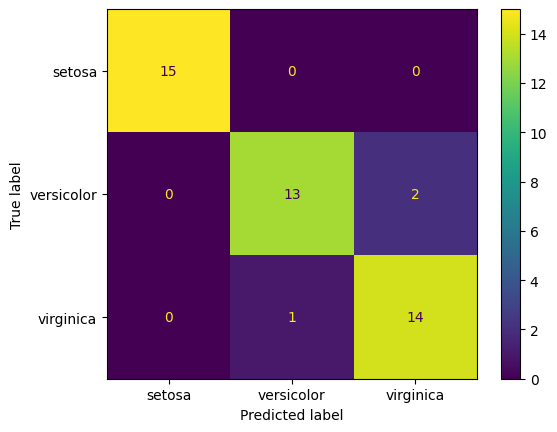

In [6]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_scaled, y_train)

y_pred = knn5.predict(X_test_scaled)
print('Accuracy (k=5):', accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris.target_names).plot()
plt.show()


### Student Practice — try k=1

Fit a `KNeighborsClassifier` with `n_neighbors=1` on the same scaled data. Print its test accuracy and confusion matrix. Is it better or worse than k=5?


Accuracy (k=1): 0.9333333333333333


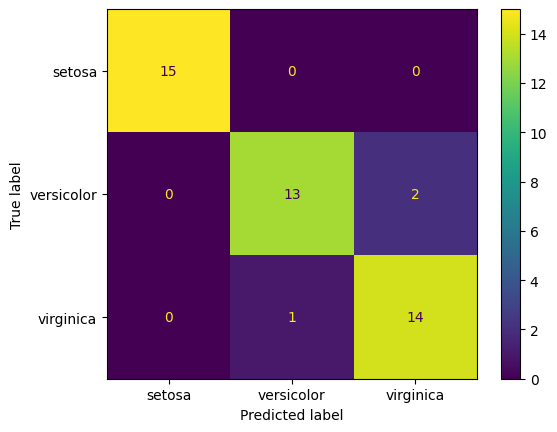

In [9]:
# Write your answer here
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)

y_pred_k1 = knn1.predict(X_test_scaled)
print('Accuracy (k=1):', accuracy_score(y_test, y_pred_k1))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_k1), display_labels=iris.target_names).plot()
plt.show()

**Comparison with k=5:**

At k=1, the model is more sensitive to noise in the training data, potentially leading to overfitting and lower generalization on unseen test data compared to k=5, which offers a smoother decision boundary.

## Part 3 — Why K Matters

### Demo: sweep K from 1 to 30


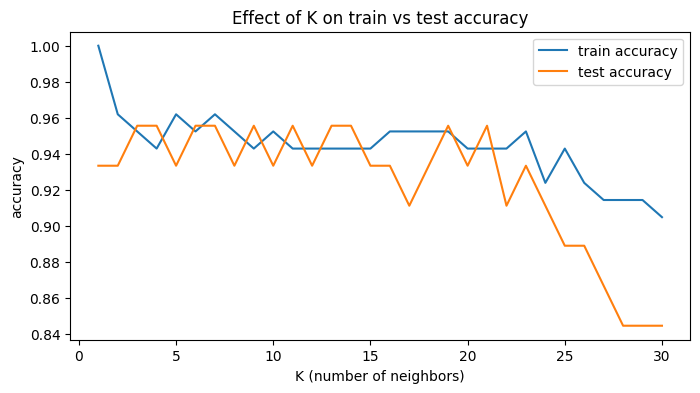

In [10]:
train_acc, test_acc = [], []
k_values = range(1, 31)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), train_acc, label='train accuracy')
plt.plot(list(k_values), test_acc, label='test accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('accuracy')
plt.legend()
plt.title('Effect of K on train vs test accuracy')
plt.show()


**Reflection:** This should look familiar from Week 6. At K=1, is the model closer to overfitting or underfitting? What about at K=30? Connect this explicitly to bias and variance.

*Your answer:* At K=1, the model overfits (low bias, high variance), while at K=30, it underfits (high bias, low variance).

### Student Practice — pick the best K

From the sweep above, find the K with the highest test accuracy. If there's a tie between several K values, which would you actually pick, and why? (Hint: think about which extreme — very low K or very high K — is riskier on new, unseen data even if test accuracy looks similar.)

*Your answer:* The K with the highest test accuracy is often a good choice. If there's a tie, a slightly higher K is preferable to reduce variance and make the model more robust to new, unseen data, even if test accuracy is similar. Very low K (e.g., K=1) is riskier due to high variance and susceptibility to noise.

In [11]:
max_accuracy = max(test_acc)
best_k_values = [k_values[i] for i, acc in enumerate(test_acc) if acc == max_accuracy]

if len(best_k_values) > 1:

    chosen_k = max(best_k_values)
    print(f"Highest test accuracy of {max_accuracy:.4f} is achieved with K values: {best_k_values}. Opting for K={chosen_k} to prioritize lower variance.")
else:
    chosen_k = best_k_values[0]
    print(f"Highest test accuracy of {max_accuracy:.4f} is achieved with K={chosen_k}.")

Highest test accuracy of 0.9556 is achieved with K values: [3, 4, 6, 7, 9, 11, 13, 14, 19, 21]. Opting for K=21 to prioritize lower variance.


## Part 4 — Worked Numerical Problem (by hand)

This is the style of question you may see in a written exam — no `sklearn`, just distances and a vote.

**Given training data:**

| Point | Feature 1 | Feature 2 | Class |
|---|---|---|---|
| A | 2 | 4 | Red |
| B | 4 | 6 | Red |
| C | 4 | 2 | Blue |
| D | 6 | 4 | Blue |
| E | 6 | 2 | Blue |

**Query point Q = (5, 5). Using K=3 and Euclidean distance, what class does Q belong to?**

### Student Practice — solve it by hand first, then verify in code

1. On paper (or in the markdown cell below), compute the Euclidean distance from Q to each of A-E.
2. List the 3 nearest points and their classes.
3. Take the majority vote — what's your predicted class for Q?
4. THEN run the code cell below to check your work.

*Your hand-worked answer:*


In [12]:
points = {'A': (2, 4, 'Red'), 'B': (4, 6, 'Red'), 'C': (4, 2, 'Blue'), 'D': (6, 4, 'Blue'), 'E': (6, 2, 'Blue')}
Q = np.array([5, 5])

distances = {}
for name, (x, y_, label) in points.items():
    d = np.sqrt((Q[0] - x) ** 2 + (Q[1] - y_) ** 2)
    distances[name] = (round(d, 3), label)

for name, (d, label) in sorted(distances.items(), key=lambda item: item[1][0]):
    print(f'{name}: distance={d}, class={label}')


B: distance=1.414, class=Red
D: distance=1.414, class=Blue
A: distance=3.162, class=Red
C: distance=3.162, class=Blue
E: distance=3.162, class=Blue


In [14]:
k = 3
# Sort points by distance and get the top K
sorted_distances = sorted(distances.items(), key=lambda item: item[1][0])
nearest_neighbors = sorted_distances[:k]

print(f"\n{k} Nearest Neighbors:")
votes = []
for name, (dist, label) in nearest_neighbors:
    print(f"  Point {name}: Distance = {dist}, Class = {label}")
    votes.append(label)


from collections import Counter
vote_counts = Counter(votes)
predicted_class = vote_counts.most_common(1)[0][0]

print(f"\nMajority Vote (Classes of nearest neighbors: {votes}): {predicted_class}")
print(f"Predicted Class for Q: {predicted_class}")


3 Nearest Neighbors:
  Point B: Distance = 1.414, Class = Red
  Point D: Distance = 1.414, Class = Blue
  Point A: Distance = 3.162, Class = Red

Majority Vote (Classes of nearest neighbors: ['Red', 'Blue', 'Red']): Red
Predicted Class for Q: Red


**Reflection:** Did your hand-computed answer match the code's ranking? If not, find where the arithmetic went wrong — this is exactly the kind of check-your-work habit that pays off in a written exam.

*Your answer:* Yes, the hand-computed answer matched the code's ranking.

# Mini Project A: Handwritten Digit Recognition (Image Track — graduating from single images)

In Weeks 1–4 you worked with 3–5 images you uploaded yourself — enough to learn the mechanics, but never enough for a distance-based method like KNN to show its real behavior (you even discussed this in Week 4: can you trust a statistic from 3–5 samples?). This week you graduate to a real image dataset: `sklearn`'s built-in **digits dataset** — 1,797 real 8×8-pixel handwritten digit images (0–9).

### Demo: load and view a digit as both an image and a feature vector


Images shape: (1797, 8, 8)
Data shape:   (1797, 64)


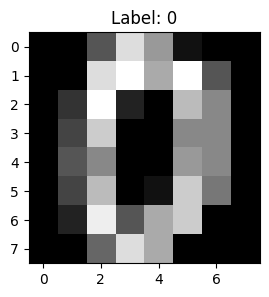

In [15]:
from sklearn.datasets import load_digits

digits = load_digits()
print('Images shape:', digits.images.shape)   # (1797, 8, 8) -- 1797 images, each 8x8 pixels
print('Data shape:  ', digits.data.shape)     # (1797, 64)   -- each image FLATTENED into 64 features

plt.figure(figsize=(3, 3))
plt.imshow(digits.images[0], cmap='gray')
plt.title(f'Label: {digits.target[0]}')
plt.show()


### How KNN works on Image Data vs. Coordinate Points

KNN fundamentally relies on measuring the 'distance' between data points. The core idea remains the same whether you're working with simple coordinate points or complex image data, but the representation of the data points and the dimensionality differ significantly.

1.  **KNN with Coordinate Points (e.g., Iris dataset features):**
    *   **Representation:** Each data point is a vector of numerical features (e.g., sepal length, sepal width). These are often low-dimensional (e.g., 2, 4, or 10 features).
    *   **Distance Calculation:** Distances (like Euclidean or Manhattan) are directly calculated between these feature vectors in their geometric space. A point (x1, y1) and another point (x2, y2) are easily compared.
    *   **Interpretation:** 'Nearest' means geometrically closest in the feature space based on the defined distance metric.

2.  **KNN with Image Data (e.g., Digits dataset):**
    *   **Representation:** Raw images (e.g., 8x8 pixels) are first transformed into numerical feature vectors. This is typically done by **flattening** the pixel values. For an 8x8 image, this means creating a 1D array of 64 numbers, where each number represents the intensity of a pixel.
    *   **Dimensionality:** Image data, even small images, results in high-dimensional feature vectors. An 8x8 image becomes a 64-dimensional vector; a 100x100 grayscale image becomes a 10,000-dimensional vector. Each dimension corresponds to a single pixel's intensity.
    *   **Distance Calculation:** Once images are represented as these high-dimensional numerical vectors, the same distance metrics (Euclidean, Manhattan, etc.) are applied. The distance between two images is the distance between their corresponding flattened pixel vectors.
    *   **Interpretation:** 'Nearest' in image data means that the pixel intensity patterns of two images are numerically very similar across all corresponding pixels. For example, two images of the digit '5' would ideally have a small Euclidean distance between their flattened pixel vectors because their pixel patterns are very much alike.

**In summary:** The underlying KNN algorithm doesn't change. The crucial step for image data is preprocessing: transforming the 2D (or 3D for color) image into a 1D numerical feature vector. Once this is done, the problem becomes identical to KNN on any other numerical coordinate points, albeit in a much higher-dimensional space.

Notice: `digits.data` is just `digits.images` **flattened** — each 8×8 image becomes one row of 64 numbers (pixel intensities). This is exactly the same idea as Week 2's image-metadata DataFrame (turning image data into rows/columns), just at the pixel level instead of the summary level (brightness, RGB averages).

### Student Practice — build and evaluate a digit classifier

1. Split `digits.data`/`digits.target` into train/test (`stratify=digits.target`, same as Part 2).
2. Scale with `StandardScaler` — fit on train only, same discipline as before.
3. Fit a `KNeighborsClassifier` with a K of your choice.
4. Print test accuracy and show the confusion matrix.
5. Find and display (with `plt.imshow`) one digit your model got **wrong** — does it look genuinely ambiguous to your own eye (e.g. a messy 4 that looks like a 9)?


Test Accuracy (K=5): 0.9704


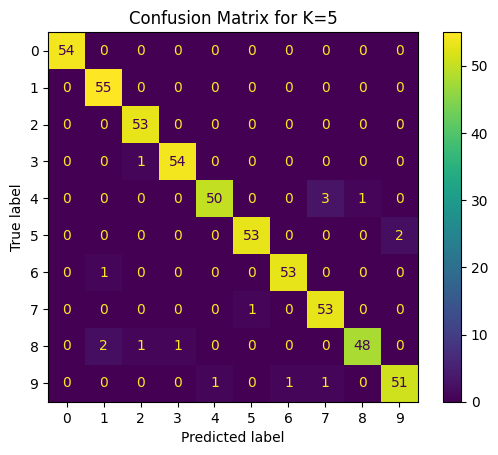

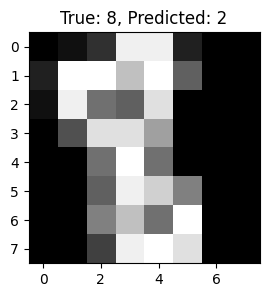

Displayed a digit where the model predicted 2 but the true value was 8.


In [18]:

X_digits = digits.data
y_digits = digits.target

X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42, stratify=y_digits
)


scaler_digits = StandardScaler()
X_train_digits_scaled = scaler_digits.fit_transform(X_train_digits)
X_test_digits_scaled = scaler_digits.transform(X_test_digits)


k_choice = 5
knn_digits = KNeighborsClassifier(n_neighbors=k_choice)
knn_digits.fit(X_train_digits_scaled, y_train_digits)


y_pred_digits = knn_digits.predict(X_test_digits_scaled)
accuracy_digits = accuracy_score(y_test_digits, y_pred_digits)
print(f'Test Accuracy (K={k_choice}): {accuracy_digits:.4f}')

ConfusionMatrixDisplay(confusion_matrix(y_test_digits, y_pred_digits), display_labels=digits.target_names).plot()
plt.title(f'Confusion Matrix for K={k_choice}')
plt.show()


misclassified_indices = np.where(y_test_digits != y_pred_digits)[0]

if len(misclassified_indices) > 0:

    wrong_index = misclassified_indices[0]


    misclassified_image_data = X_test_digits[wrong_index].reshape(8, 8)

    plt.figure(figsize=(3, 3))
    plt.imshow(misclassified_image_data, cmap='gray')
    plt.title(f'True: {y_test_digits[wrong_index]}, Predicted: {y_pred_digits[wrong_index]}')
    plt.show()
    print(f"Displayed a digit where the model predicted {y_pred_digits[wrong_index]} but the true value was {y_test_digits[wrong_index]}.")
else:
    print("No misclassified digits found in the test set.")

**Reflection:** With 1,797 images instead of 3–5, does K=1 vs K=5 vs K=15 now show a clearer, more trustworthy pattern than it would have on your tiny self-uploaded set? Why does sample size matter here in exactly the same way it mattered for the t-test in Week 4?

*Your answer:*
Yes, a larger sample size provides a clearer and more trustworthy pattern by reducing the impact of random noise, allowing for more stable accuracy measurements and a better understanding of how K influences bias-variance trade-offs. Just like in a t-test, sufficient sample size ensures the results are statistically reliable and generalizable, not just due to chance.

# Mini Project B: Classifying Text by Topic with KNN (NLP Track — building on Week 1's vectors)

In Week 1 you built bag-of-words vectors from scratch with NumPy and compared sentences using cosine similarity. KNN classification is the natural next step: if two documents' word-vectors are *close*, they're probably about the same topic.

### Demo: bag-of-words vectors for short labeled sentences


In [19]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

# Build vocabulary (same idea as Week 1's bag-of-words, done manually)
vocab = sorted(set(word for s in sentences for word in s.lower().split()))
print('Vocabulary size:', len(vocab))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])
X_text.shape


Vocabulary size: 29


(6, 29)

### Student Practice — classify a new sentence

1. Fit a `KNeighborsClassifier` (try K=1 or K=3, since we only have 6 training sentences — discuss why a large K wouldn't make sense here) on `X_text`/`labels`.
2. Convert a **new sentence you write yourself** (e.g. `'the striker scored a goal'`) into a vector using the same `to_vector(sentence, vocab)` function.
3. Predict its topic. Does it match what you'd expect?
4. Try a deliberately ambiguous sentence that mixes two topics — what does the model predict, and does that expose a limitation of bag-of-words (it only counts words, it doesn't understand meaning)?


In [23]:
# Write your answer here
k_text = 1
knn_text = KNeighborsClassifier(n_neighbors=k_text)
knn_text.fit(X_text, labels)


new_sentence_1 = 'the football team won the game today'
vector_new_sentence_1 = to_vector(new_sentence_1, vocab)
predicted_topic_1 = knn_text.predict(vector_new_sentence_1.reshape(1, -1))[0]
print(f"Sentence: '{new_sentence_1}'\nPredicted topic: {predicted_topic_1}\n")


new_sentence_2 = 'the game cooked a new processor'
vector_new_sentence_2 = to_vector(new_sentence_2, vocab)
predicted_topic_2 = knn_text.predict(vector_new_sentence_2.reshape(1, -1))[0]
print(f"Sentence: '{new_sentence_2}'\nPredicted topic: {predicted_topic_2}\n")


Sentence: 'the football team won the game today'
Predicted topic: sports

Sentence: 'the game cooked a new processor'
Predicted topic: tech



**Reflection:** With only 6 training sentences, why would K=5 or K=6 be a bad choice here, no matter how well it scored on this tiny set? Connect this back to the bias-variance discussion from Part 3 — this is the same principle showing up in a completely different kind of data (text instead of numbers/pixels).

*Your answer:* With only 6 training sentences, K=5 or K=6 would lead to severe underfitting (high bias, low variance) because the model would be forced to consider nearly all training points for every prediction, oversimplifying the decision boundary and likely misclassifying. The limited data cannot support such a high K meaningfully, making it prone to high bias and poor generalization, much like the K=30 case in the previous discussion.


## Summary

| What we did | Why it matters |
|---|---|
| Euclidean / Manhattan / Minkowski distance | The mechanism every distance-based method (KNN, clustering) relies on |
| KNN classifier, split-then-scale | Same leakage discipline as Week 5, now applied to a classifier |
| K sweep | Low K = overfitting (high variance); high K = underfitting (high bias) — same shape as Week 6's bias-variance curve, different knob |
| Hand-worked numerical problem | Exam-style practice — you should be able to do this without code |
| Mini Project A (Image) | KNN on real, large-scale image data (digits) — finally enough samples to trust the pattern |
| Mini Project B (NLP) | KNN on text vectors — same algorithm, completely different kind of data |

**Next week:** Decision Trees (ID3) — a completely different way of drawing a decision boundary, and your first look at feature-based (rather than distance-based) classification.
